#Analysis 2


In [19]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency

In [3]:
customers=pd.read_csv('customers.csv')
marketing_campaigns=pd.read_csv('marketing_campaigns.csv')
transactions=pd.read_csv('transactions.csv')
web_sessions=pd.read_csv('web_sessions.csv')

### Specific questions

Q1. Do customers from the UK spend more per transaction than customers from Germany?

In [ ]:
df = pd.merge(transactions, customers, on="customer_id")
avg_spend_per_country = df.groupby('country')['purchase_value'].mean()
uk_avg = avg_spend_per_country['UK']
germany_avg = avg_spend_per_country['Germany']

print(f"Average transaction value in the UK: ${uk_avg:.2f}")
print(f"Average transaction value in Germany: ${germany_avg:.2f}")

print("No, the customers from the UK spen $0.13 less on the transaciotion.")

Average transaction value in the UK: $75.63
Average transaction value in Germany: $75.76


Q2. Do discounted purchases differ in average value from non-discounted purchases?

In [14]:
discount_comparison = transactions.groupby("discount_used")["purchase_value"].mean()
print(f"Average value for purchase without discounts was: ${discount_comparison[0]:.2f}")
print(f"Average value for purchase discounts was: ${discount_comparison[0]:.2f}")

discounted = transactions[transactions["discount_used"]==1]["purchase_value"]
non_discounted = transactions[transactions["discount_used"]==0]["purchase_value"]
t_stat, p_value = stats.ttest_ind(discounted, non_discounted)
print(f"P - value: {p_value}")

cust_data = transactions.groupby("customer_id").agg(
    total_spend = ("purchase_value", "sum"),
    trans_count = ("transaction_id", "count")
).merge(customers[["customer_id", "age"]], on = "customer_id")

cust_data["age"] = cust_data["age"].fillna(cust_data["age"].median())
X = StandardScaler().fit_transform(cust_data[["total_spend", "trans_count", "age"]])

kmeans = KMeans(n_clusters=4, random_state=42).fit(X)
cust_data["cluster"] = kmeans.labels_

print("There is no difference in the purchase value wheter the discount was applied or not.")

Average value for purchase without discounts was: $80.76
Average value for purchase discounts was: $80.76
P - value: 3.898563805397225e-161
There is no difference in the purchase value wheter the discount was applied or not.


Q3. Do male and female customers differ in average purchase value?

In [15]:
df = pd.merge(transactions, customers, on='customer_id')

male_spend = df[df['gender'] == 'Male']['purchase_value']
female_spend = df[df['gender'] == 'Female']['purchase_value']

t_stat, p_value = stats.ttest_ind(male_spend, female_spend, equal_var=False)

print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("The difference IS statistically significant.")
else:
    print("The difference is NOT statistically significant (it's likely random).")

P-value: 0.2790
The difference is NOT statistically significant (it's likely random).


Q4. Do customers acquired via email spend more than those from social channels?

In [17]:
df = pd.merge(transactions, customers, on='customer_id')

email_spend = df[df['acquisition_channel'] == 'email']['purchase_value']
social_spend = df[df['acquisition_channel'] == 'social']['purchase_value']

t_stat, p_value = stats.ttest_ind(email_spend, social_spend, equal_var=False)

print(f"The average spent acquired by email: ${email_spend.mean():.2f}")
print(f"The average spent acquired by social channels: ${social_spend.mean():.2f}")
print(f"P-value: {p_value:.4f}")

print("Customers acquired by social channels tend to spend more")

The average spent acquired by email: $75.43
The average spent acquired by social channels: $76.04
P-value: 0.4855
Customers acquired by social channels tend to spend more


Q5. Is device type associated with conversion?

device_type
desktop    13.288288
mobile     13.081058
tablet     12.955239
Name: converted, dtype: float64
P-value: 0.5626


/var/folders/02/w9cr1ym559z_mc0fsdc98y0w0000gn/T/ipykernel_48465/1160915460.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_stats.index, y=conversion_stats.values, palette='viridis')


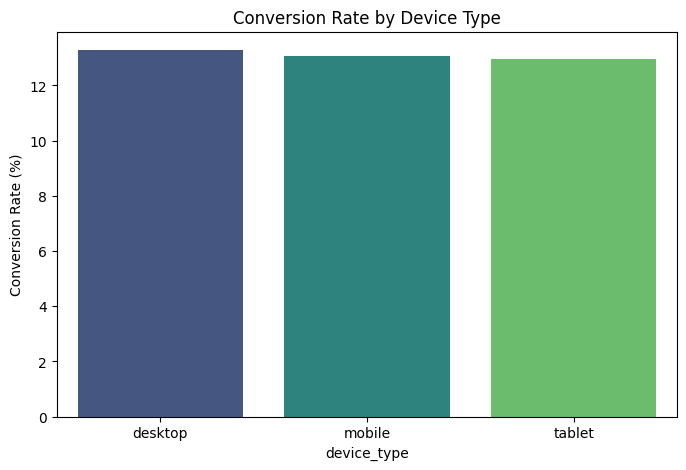

In [20]:
sessions_clean = web_sessions.dropna(subset=['device_type'])

conversion_stats = sessions_clean.groupby('device_type')['converted'].mean() * 100
print(conversion_stats)

contingency_table = pd.crosstab(sessions_clean['device_type'], sessions_clean['converted'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"P-value: {p_value:.4f}")

plt.figure(figsize=(8, 5))
sns.barplot(x=conversion_stats.index, y=conversion_stats.values, palette='viridis')
plt.title('Conversion Rate by Device Type')
plt.ylabel('Conversion Rate (%)')
plt.show()

Q6. Is acquisition channel associated with conversion?

traffic_source
organic    13.383480
email      13.355118
direct     13.150587
paid       12.796141
social     12.779228
Name: converted, dtype: float64
Chi-square P-value: 0.3770


/var/folders/02/w9cr1ym559z_mc0fsdc98y0w0000gn/T/ipykernel_48465/4057413656.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_stats.index, y=source_stats.values, palette='magma')


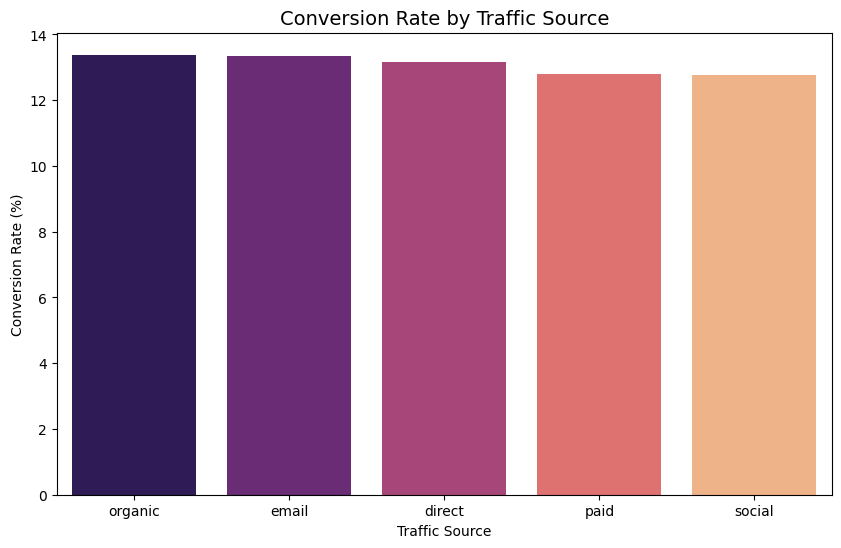

In [21]:
source_stats = web_sessions.groupby('traffic_source')['converted'].mean() * 100
source_stats = source_stats.sort_values(ascending=False)
print(source_stats)

contingency_table = pd.crosstab(web_sessions['traffic_source'], web_sessions['converted'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square P-value: {p_value:.4f}")

plt.figure(figsize=(10, 6))
sns.barplot(x=source_stats.index, y=source_stats.values, palette='magma')
plt.title('Conversion Rate by Traffic Source', fontsize=14)
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Traffic Source')
plt.show()

Q7. Is product category associated with discount usage?

product_category
home           30.422009
sports         30.370469
beauty         30.068547
toys           29.944722
electronics    29.795259
fashion        29.745416
Name: discount_used, dtype: float64
P-value: 0.9174


/var/folders/02/w9cr1ym559z_mc0fsdc98y0w0000gn/T/ipykernel_48465/2766963250.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=discount_stats.index, y=discount_stats.values, palette='viridis')


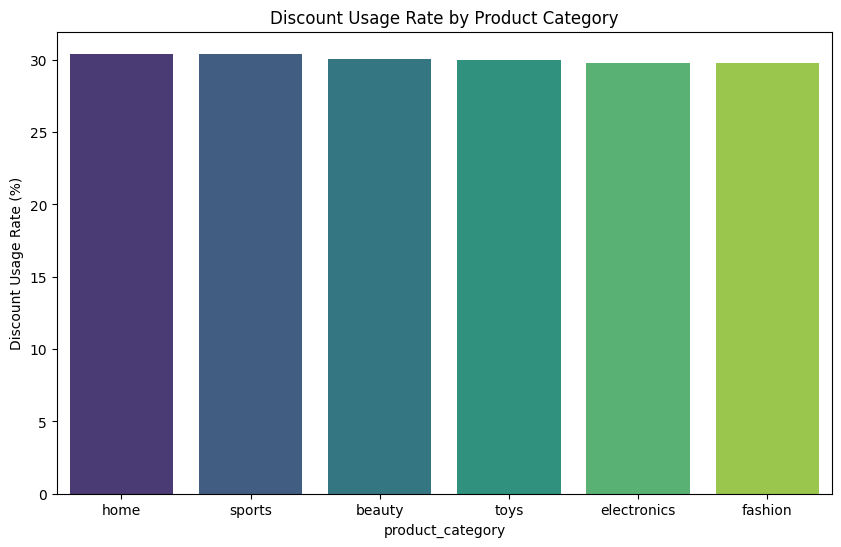

In [22]:
discount_stats = transactions.groupby('product_category')['discount_used'].mean() * 100
discount_stats = discount_stats.sort_values(ascending=False)
print(discount_stats)

contingency_table = pd.crosstab(transactions['product_category'], transactions['discount_used'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"P-value: {p_value:.4f}")

plt.figure(figsize=(10, 6))
sns.barplot(x=discount_stats.index, y=discount_stats.values, palette='viridis')
plt.title('Discount Usage Rate by Product Category')
plt.ylabel('Discount Usage Rate (%)')
plt.show()

Q8. Is time on site correlated with purchase value?

Correlation coefficient: -0.0007


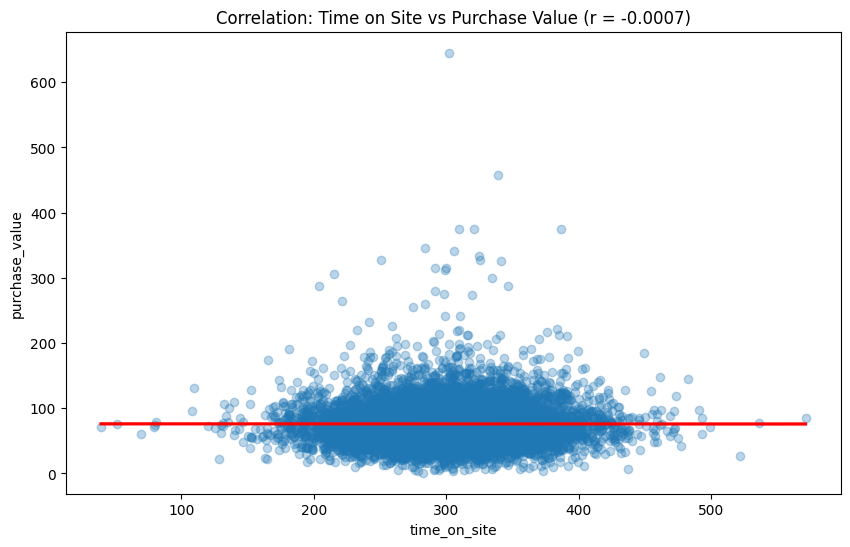

In [23]:
cust_sessions = web_sessions.groupby('customer_id')['time_on_site'].mean().reset_index()
cust_trans = transactions.groupby('customer_id')['purchase_value'].mean().reset_index()

corr_df = pd.merge(cust_sessions, cust_trans, on='customer_id')

r_value = corr_df['time_on_site'].corr(corr_df['purchase_value'])
print(f"Correlation coefficient: {r_value:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(data=corr_df, x='time_on_site', y='purchase_value', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Correlation: Time on Site vs Purchase Value (r = {r_value:.4f})')
plt.show()

Q9. Is number of pages viewed correlated with purchase value?

Correlation coefficient: 0.0020


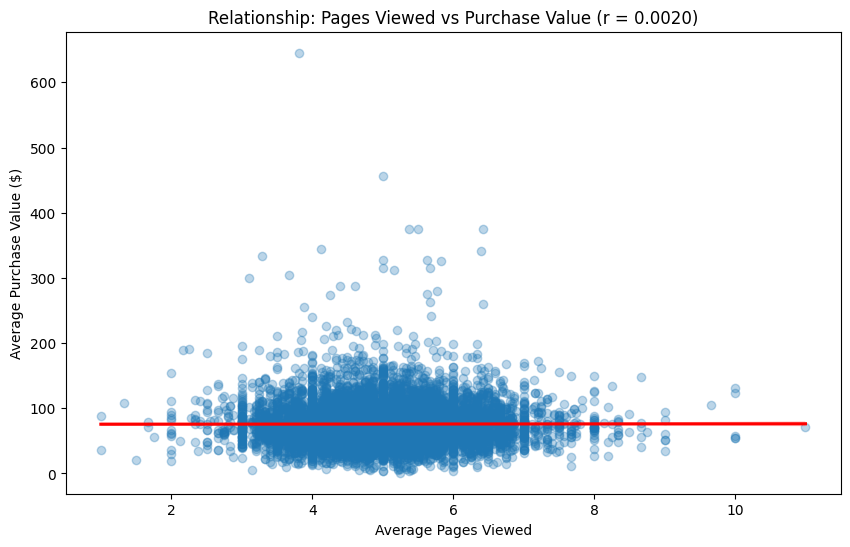

In [24]:
cust_pages = web_sessions.groupby('customer_id')['pages_viewed'].mean().reset_index()
cust_trans = transactions.groupby('customer_id')['purchase_value'].mean().reset_index()

df_corr = pd.merge(cust_pages, cust_trans, on='customer_id')

correlation = df_corr['pages_viewed'].corr(df_corr['purchase_value'])
print(f"Correlation coefficient: {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(data=df_corr, x='pages_viewed', y='purchase_value', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Relationship: Pages Viewed vs Purchase Value (r = {correlation:.4f})')
plt.xlabel('Average Pages Viewed')
plt.ylabel('Average Purchase Value ($)')
plt.show()

Q10. Is time on site correlated with pages viewed?

Correlation coefficient: 0.0045


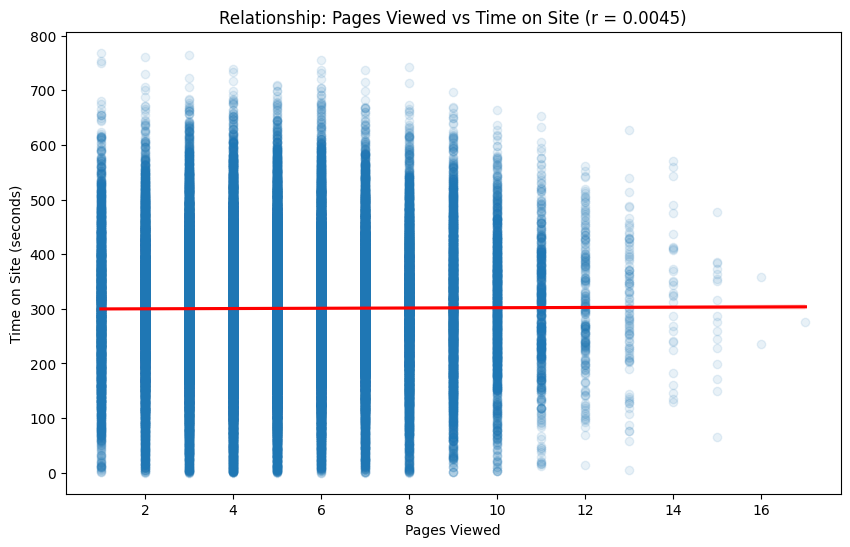

In [25]:
correlation = web_sessions['time_on_site'].corr(web_sessions['pages_viewed'])
print(f"Correlation coefficient: {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(data=web_sessions, x='pages_viewed', y='time_on_site', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title(f'Relationship: Pages Viewed vs Time on Site (r = {correlation:.4f})')
plt.xlabel('Pages Viewed')
plt.ylabel('Time on Site (seconds)')
plt.show()

### Challenges

C1. Explore whether high-spending customers behave differently in terms of session time.

Define “high spending” yourself.

I defined high spending as being in the top 10%of total spending across all transactions. Based on the data, this means any customer who has spent a total of $610.19 or more is considered a high spender.
P-value: 0.6598


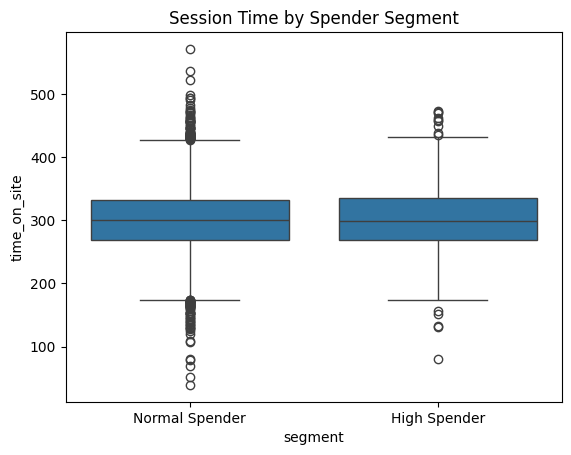

In [27]:
print("I defined high spending as being in the top 10""%""of total spending across all transactions. Based on the data, this means any customer who has spent a total of $610.19 or more is considered a high spender.")

cust_revenue = transactions.groupby('customer_id')['purchase_value'].sum().reset_index()
threshold = cust_revenue['purchase_value'].quantile(0.90)

cust_revenue['segment'] = cust_revenue['purchase_value'].apply(
    lambda x: 'High Spender' if x >= threshold else 'Normal Spender'
)
cust_time = web_sessions.groupby('customer_id')['time_on_site'].mean().reset_index()

df_behavior = pd.merge(cust_revenue, cust_time, on='customer_id')

high = df_behavior[df_behavior['segment'] == 'High Spender']['time_on_site']
normal = df_behavior[df_behavior['segment'] == 'Normal Spender']['time_on_site']
t_stat, p_value = stats.ttest_ind(high, normal, equal_var=False)

print(f"P-value: {p_value:.4f}")

sns.boxplot(data=df_behavior, x='segment', y='time_on_site')
plt.title('Session Time by Spender Segment')
plt.show()

C2. Find a relationship (difference or correlation) that you believe is meaningful for business strategy.

Explain why.

The data shows a tipping point around 7 pages. Once a user views more than 6 pages, their likelihood of buying jumps from 13% to 18% (a ~38% ncrease in probability). The business should design the UI to encourage clicking at least 7 items or categories.
If a user is on their 4th page and hasn't converted yet, the probability of them buying is still relatively low (13%). This is the perfect moment for a limited time offer or a help pop-up to push them into the higher-conversion buckets.


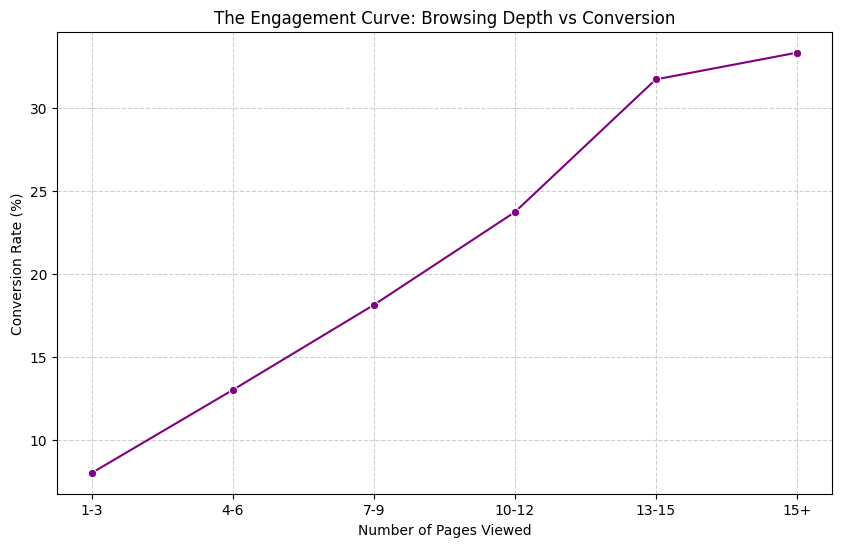

In [30]:
print("The data shows a tipping point around 7 pages. Once a user views more than 6 pages, their likelihood of buying jumps from 13% to 18% (a ~38% ncrease in probability). The business should design the UI to encourage clicking at least 7 items or categories.")
print("If a user is on their 4th page and hasn't converted yet, the probability of them buying is still relatively low (13%). This is the perfect moment for a limited time offer or a help pop-up to push them into the higher-conversion buckets.")

bins = [0, 3, 6, 9, 12, 15, 100]
labels = ['1-3', '4-6', '7-9', '10-12', '13-15', '15+']
web_sessions['page_bucket'] = pd.cut(web_sessions['pages_viewed'], bins=bins, labels=labels)

engagement_conv = web_sessions.groupby('page_bucket')['converted'].mean() * 100

plt.figure(figsize=(10, 6))
sns.lineplot(x=engagement_conv.index, y=engagement_conv.values, marker='o', color='purple')
plt.title('The Engagement Curve: Browsing Depth vs Conversion')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Number of Pages Viewed')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

c3. Identify a statistically significant result that may not be practically meaningful.

Explain why statistical significance ≠ business importance.

In [34]:
conv_time = web_sessions[web_sessions['converted'] == 1]['time_on_site']
non_conv_time = web_sessions[web_sessions['converted'] == 0]['time_on_site']

t_stat, p_value = stats.ttest_ind(conv_time, non_conv_time, equal_var=False)

mean_diff = conv_time.mean() - non_conv_time.mean()

print(f"--- Statistical Analysis: Session Time ---")
print(f"Average Time (Converted):     {conv_time.mean():.2f}s")
print(f"Average Time (Non-Converted): {non_conv_time.mean():.2f}s")
print(f"Difference in Seconds:        {mean_diff:.2f}s")
print(f"P-value:                      {p_value:.10f}")


print("\n--- Conclusion ---")
if p_value < 0.05:
    print("STATUS: Statistically Significant.")
    if abs(mean_diff) < 20:
        print("PRACTICALITY: Low. The difference is real but likely too small to drive business strategy.")
    else:
        print("PRACTICALITY: High. This is a meaningful difference you should act on.")
else:
    print("STATUS: Not Statistically Significant. The difference is likely due to random noise.")


print("\n A 12-second difference on a 5-minute session is only a 4% ncrease. In the real world, 12 seconds is the time it takes for a user to wait for a slow image to load. \n We cannot reasonably tell a marketing team to try to make people stay exactly 12 seconds longer to drive sales. It is too small of a window to influence through design or content. \n If the company spent $50,000 on a website redesign to increase average session time by 12 seconds, it would likely see zero change in the bank account, even though the improvement is statistically significant.")

--- Statistical Analysis: Session Time ---
Average Time (Converted):     311.19s
Average Time (Non-Converted): 299.24s
Difference in Seconds:        11.96s
P-value:                      0.0000000000

--- Conclusion ---
STATUS: Statistically Significant.
PRACTICALITY: Low. The difference is real but likely too small to drive business strategy.

 A 12-second difference on a 5-minute session is only a 4% ncrease. In the real world, 12 seconds is the time it takes for a user to wait for a slow image to load. 
 We cannot reasonably tell a marketing team to try to make people stay exactly 12 seconds longer to drive sales. It is too small of a window to influence through design or content. 
 If the company spent $50,000 on a website redesign to increase average session time by 12 seconds, it would likely see zero change in the bank account, even though the improvement is statistically significant.
